# Sampling strategies and Active Learning 

In this notebook, the process of 1D function prediction followed in the [intro notebook](./notebook_test_GP.py) is applied to different types of functions. The code detailed from that notebook has been generalised to a `Surrogate` class in `exact_gp_model.py` that wraps the workflow from defining the test function to obtaining infered values. 

Specifically, the a class `Surrogate` model is defined that can be instanciated with: 
- a Callable `func` object that represents the function
- a tuple `bounds` that represent the bounds on which the function should be modeled
- a boolean `noise` that decides whether observation noise should be assumed on the data (internally, this sets the likelihood of the used GP model to either a fixed gaussian noise with tiny variance, or a learned noise)
- a training sample size `sample_size` that decides the number of randomly observed points to start with
- (optionally) an input sample `input_sample`: If given, this overrides the random training sample generation and `input_sample` is used instead. 

In [19]:
%load_ext autoreload
%autoreload 2

import numpy as np 
import torch 
from matplotlib import pyplot as plt 
import scienceplots 
plt.style.use("science")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [20]:
## Runs the test 
## %run exact_gp_model.py

## Effect of input sampling strategies 

The input sampling strategy is roughly the method of choosing the training points in the input space. From a purely interpolation point of view, their distribution can affect the efficiency of the final reconstruction. As extreme examples, the following GP models of the same function illustrate why sampling matters. 

At a fixed training sample size $N=10$, three sampling methods are used: a (purely) random sample from an uniform distribution, an sample with 10 equally spaced points, a [pseudo-random sample](https://en.wikipedia.org/wiki/Latin_hypercube_sampling).

In [4]:
from exact_gp_model import Surrogate 
from scipy.stats import qmc 

def f(x):
    return torch.cos(torch.sin(x)) * torch.cos(x)

bounds = (-10, 10)
sample_size = 10

random_sample = torch.from_numpy(np.random.uniform(bounds[0], bounds[1], sample_size))
spaced_sample = torch.linspace(bounds[0], bounds[1], sample_size)

qmc_sample = qmc.LatinHypercube(d=1, scramble=True).random(sample_size)
qmc_sample = (1 - qmc_sample) * bounds[0] + qmc_sample * bounds[1] 
lhs_sample = torch.from_numpy(qmc_sample.reshape(sample_size,)) 

samples = {
    "Random": random_sample,
    "Equally spaced": spaced_sample,
    "LHS": lhs_sample
}

gps = {
    sample_name: Surrogate(
        func=f,
        bounds=bounds,
        noise=False,
        input_sample=sample
    )

    for sample_name, sample in samples.items()
}

train_results = {}

training_iters = 50 
for gp, model in gps.items():
    train_results[gp] = model.train(training_iters=50, details=True)

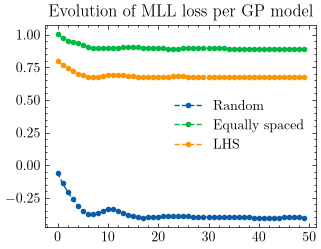

In [5]:
## Show training evolution 
plt.figure() 
for name, model in gps.items():
    plt.plot(range(training_iters), train_results[name]["loss"], label=name, marker='.', linestyle='--')

plt.title("Evolution of MLL loss per GP model")
plt.legend() 

/home/rraanto/.local/lib/python3.13/site-packages/gpytorch/likelihoods/gaussian_likelihood.py:350: GPInputWarning: You have passed data through a FixedNoiseGaussianLikelihood that did not match the size of the fixed noise, *and* you did not specify noise. This is treated as a no-op.
  warnings.warn(


Text(0.5, 0.98, 'Different prediction means from different training sample strategies')

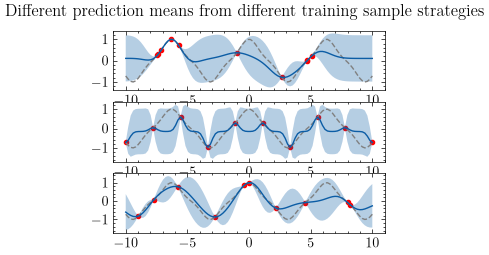

In [6]:
fig, axes = plt.subplots(3)
axes = axes.flatten() 

test_x = torch.linspace(*bounds, 100)


i=0
for name, model in gps.items(): 
    train_x, train_y = model.get_training_data() 
    ## true function 
    axes[i].plot(test_x, f(test_x), color='grey', linestyle='--', label='Initial function')

    ## training sample 
    axes[i].scatter(train_x, train_y, color='red', marker='.')
    
    model_y, lower_conf, upper_conf = model(test_x)
    axes[i].plot(test_x, model_y, linestyle='-')

    axes[i].fill_between(test_x, lower_conf, upper_conf, alpha=0.3)

    # axes[i].set_title(f"GP from {name} sample", fontsize=10, pad=4)
    i+= 1 

plt.suptitle("Different prediction means from different training sample strategies")
    

Visually, the LHS initial sample allows for a more certain estimation at the new points. The random uniform sample does not perform so much worse, if not for clearly underpopulated regions (for example $\{ x \geq 5 \}$, which is exactly the type of situations that quasi-random samples tend to avoid). 

The design with equally spaced points along the interval performs the worst as the tendency to fallback to the constant zero mean is almost very visible in between the interpolation points. This may be due to a poor choice of Kernel that takes too much into account the distance between points. 

For a finer comparison of the three methods, with a training sample size $n \geq 1$, the prediction accuracy of a metamodel $g$ is quantified by the Root-Mean-Squared-Error (RMSE), or simply $L^2$ norm: 

$$
\| g - f \|_{L^2} \approx \sqrt{ \sum \limits_{i=1}^N (g(x_i) - f(x_i))^2}
$$

Similarly, the model global confidence is quantified by the $L^2$ norm of the confidence region size: 

$$
\| g_{upper} - g_{lower} \|_{L^2}
$$

Both quantities being computed on a discretization $a=x_1 \leq \dots x_i = a + \frac{i-1}{N} \leq \dots \leq x_N = b$ of the interval $[a, b]$. 

In [7]:
def RMSE(f, g, bounds=(-10, 10), Nx=100):
    """
    Computes the RMSE between two functions 
    """
    x = torch.linspace(*bounds, Nx)
    return torch.linalg.norm((f(x) - g(x)) / Nx)

def gp_precision(f, gp_model, Nx=100):
    return RMSE(f, lambda x: gp_model(x)[0], bounds=gp_model.bounds, Nx=Nx)


In [8]:
## Evolution of the errors and confidence with respect to training set data 
## the three previously defined models are used on a training sample of size 50 now (sequentially acquired)
bounds = (-10, 10)
sample_size = 50

random_sample = torch.from_numpy(np.random.uniform(bounds[0], bounds[1], sample_size))
spaced_sample = torch.linspace(bounds[0], bounds[1], sample_size)

qmc_sample = qmc.LatinHypercube(d=1, scramble=True).random(sample_size)
qmc_sample = (1 - qmc_sample) * bounds[0] + qmc_sample * bounds[1] 
lhs_sample = torch.from_numpy(qmc_sample.reshape(sample_size,)) 

samples = {
    "Random": random_sample,
    "Equally spaced": spaced_sample,
    "LHS": lhs_sample
}

## GPs initially with only the first four points of the sample 

start_size = 4
gps = {
    sample_name: Surrogate(
        func=f,
        bounds=bounds,
        noise=False,
        input_sample=sample[:start_size]
    )

    for sample_name, sample in samples.items()
}

# data about precision and confidence 
## stores precision (RMSE) for each training sample size for each model 
## and confidence 
model_info = {
    model_name: {
        "precision": [],
        "confidence": []
    }
    for model_name in gps 
}

for name, model in gps.items():
    model.train()
    model_info[name]["precision"].append(gp_precision(f, model))

    ## l2 norm between upper and lower confidence 
    model_info[name]["confidence"].append(RMSE(lambda x: model(x)[1], lambda x: model(x)[2]))
    
## sequential acquisition of training data 
for i in range(start_size, sample_size):
    for name, model in gps.items():
        model.acquire_training_data(samples[name][i])
        model.train()
        model_info[name]["precision"].append(gp_precision(f, model))
        model_info[name]["confidence"].append(RMSE(lambda x: model(x)[1], lambda x: model(x)[2]))


/home/rraanto/.local/lib/python3.13/site-packages/gpytorch/distributions/multivariate_normal.py:375: NumericalWarning: Negative variance values detected. This is likely due to numerical instabilities. Rounding negative variances up to 1e-06.
  warnings.warn(
/home/rraanto/.local/lib/python3.13/site-packages/linear_operator/utils/cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-06 to the diagonal
  warnings.warn(
/home/rraanto/.local/lib/python3.13/site-packages/gpytorch/distributions/multivariate_normal.py:375: NumericalWarning: Negative variance values detected. This is likely due to numerical instabilities. Rounding negative variances up to 1e-10.
  warnings.warn(
/home/rraanto/.local/lib/python3.13/site-packages/linear_operator/utils/cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(
/home/rraanto/.local/lib/python3.13/site-packages/linear_operator/utils/cholesky.py:41: NumericalWarning: A not p.d., added jitter o

Text(0, 0.5, 'Confidence region size')

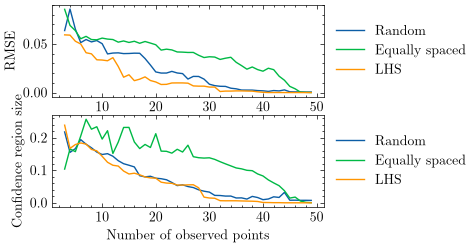

In [9]:
## Plot precision and confidence 

fig, (plt1, plt2) = plt.subplots(2)

## training sizes considered above 
size_range = range(start_size-1, sample_size) 

for model_name, info in model_info.items():
    ## precision 
    plt1.plot(size_range, info["precision"], label=model_name)
    plt2.plot(size_range, info["confidence"], label=model_name)

plt1.legend(loc="center left", bbox_to_anchor=(1, 0.5)) 
plt1.set_xlabel("Training size") 
plt1.set_ylabel("RMSE")

plt2.legend(loc="center left", bbox_to_anchor=(1, 0.5)) 
plt2.set_xlabel("Number of observed points")
plt2.set_ylabel("Confidence region size") 

## Active learning 

Active learning is a method to optimise the accuracy, measured by the model output variance provided by the GP itself, given a computational budget. Essentially, given a current model $g = \mathcal N(\mu(-), \sigma^2(-))$ that has been conditionned on $i-1$ points $x_1, \dots, x_{i-1}$, a new point within the input space is acquired where the current model is most uncertain: 

$$
x_{new} \in \arg \max\limits_{x \in [a, b]} \sigma^2(x)
$$


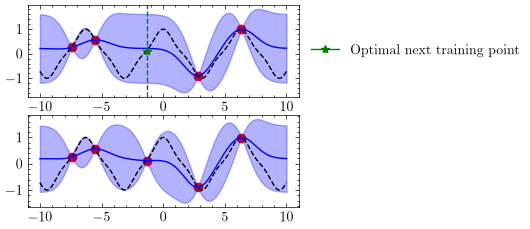

In [15]:
gp = Surrogate(func=f, bounds=bounds, input_sample=random_sample[:4])
gp.train()

test_x = torch.linspace(*bounds, 1000)

fig, (plt1, plt2) = plt.subplots(2) 
mean, lower, upper = gp(test_x)

train_x, train_y = gp.get_training_data()

plt1.plot(test_x, f(test_x), "k--")
plt1.plot(test_x, mean, color="blue")
plt1.scatter(train_x, train_y, marker="o", color="red")
plt1.fill_between(test_x, lower, upper, alpha=0.3, color="blue")

next_x_idx = torch.argmax((upper - lower)**2)
next_x = test_x[next_x_idx]

plt1.plot(next_x, f(next_x), marker="*", color="green", label="Optimal next training point")
plt1.axvline(x=next_x, linestyle="--", color="green") 
plt1.legend(loc="center left", bbox_to_anchor=(1, 0.5)) 

gp.acquire_training_data(next_x) 
gp.train() 
mean, lower, upper = gp(test_x)

train_x, train_y = gp.get_training_data()
## after acquiring that point 
plt2.plot(test_x, f(test_x), "k--")
plt2.plot(test_x, mean, color="blue")
plt2.scatter(train_x, train_y, marker="o", color="red")
plt2.fill_between(test_x, lower, upper, alpha=0.3, color="blue")

In the next numerical experiments, the preceding method is applied to a Gaussian process initially conditionned on $i=4$ observed points sampled from a uniform distribution, and is sequentially enriched with up to $i=50$ points. The evolution of its precision and its confidence is then studied. 

In [17]:
# Active learning on a new GP 

start_size, sample_size = 4, 50 

gp_AL = Surrogate(func=f, bounds=bounds, input_sample=random_sample[:start_size])
gp_AL.train() 

precision_AL = [gp_precision(f, gp_AL)]
confidence_AL = [RMSE(lambda x: gp_AL(x)[1], lambda x: gp_AL(x)[2])]

## the discretised interval on which the next point is searched 
search_x = torch.linspace(*bounds, 1000)
for i in range(start_size, sample_size):
    ## Pick the next point that minimises the output variance 
    _, lower_conf, upper_conf = gp_AL(search_x)
    next_idx = torch.argmax(torch.abs(lower_conf - upper_conf))

    ## acquire the new data 
    gp_AL.acquire_training_data(search_x[next_idx])
    gp_AL.train() 

    ## update model precision info 
    precision_AL.append(gp_precision(f, gp_AL))
    confidence_AL.append(RMSE( lambda x: gp_AL(x)[1], lambda x: gp_AL(x)[2]))

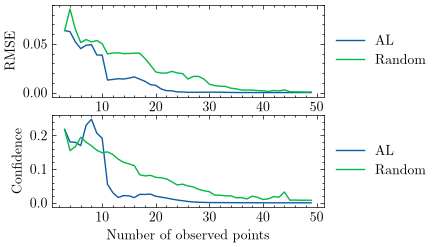

In [18]:
## Plot against random sample enrichment 

## from the previously used models 
precision_random, confidence_random = model_info["Random"]["precision"], model_info["Random"]["confidence"]

size_range = range(start_size - 1, sample_size)

fig, (plt1, plt2) = plt.subplots(2)

## Model precision 
plt1.plot(size_range, precision_AL, label="AL")
plt1.plot(size_range, precision_random, label="Random")
plt1.set_xlabel("Number of observed points")
plt1.set_ylabel("RMSE") 
plt1.legend(loc="center left", bbox_to_anchor=(1, 0.5))

# Model confidence 
plt2.plot(size_range, confidence_AL, label="AL")
plt2.plot(size_range, confidence_random, label="Random")
plt2.set_xlabel("Number of observed points")
plt2.set_ylabel("Confidence")
plt2.legend(loc="center left", bbox_to_anchor=(1, 0.5))
